# AnemoScan: Ai - Based Early Detection Of Anemia From Nail & Conjunctiva Images
## Block 1 - Dataset and Preprocessing - Nails Dataset
- This notebook focuses on preparing the nails dataset for model development. The workflow includes dataset organization, dataset splitting into training, validation, and test sets, image preprocessing, and data augmentation techniques to enhance model performance and generalization.

## 1. Import Required Libraries
- This section imports all necessary libraries for data handling, preprocessing, and visualization.

In [3]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 2. Filename Standardization and Data Cleaning
- All images were renamed using a standardized naming convention to ensure uniqueness and prevent file conflicts. Non-image and corrupted files were excluded.

In [5]:
base_path = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Nails'

folders = ['Anemic', 'Non_Anemic']

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    files = os.listdir(folder_path)

    count = 1
    for file in files:
        old_path = os.path.join(folder_path, file)

        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        new_name = f'nail_{folder.lower()}_{count:05d}.jpg'
        new_path = os.path.join(folder_path, new_name)

        os.rename(old_path, new_path)
        count += 1

print('Renaming completed successfully!')

Renaming completed successfully!


## 3. Dataset Splitting
 - The dataset was split into training (70%), validation (15%), and testing (15%) subsets using an automated script to ensure reproducibility and eliminate human error.

In [7]:
def create_folders(base_path):
    for split in ['train', 'val', 'test']:
        for cls in ['Anemic', 'Non_Anemic']:
            path = os.path.join(base_path, split, cls)
            os.makedirs(path, exist_ok = True)

def split_data(base_path, split_ratio = (0.7, 0.15, 0.15)):
    for class_name in ['Anemic', 'Non_Anemic']:
        src = os.path.join(base_path, class_name)
        images = [img for img in os.listdir(src)
          if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        random.shuffle(images)

        train_split = int(len(images) * split_ratio[0])
        val_split = int(len(images) * (split_ratio[0] + split_ratio[1]))

        train_imgs = images[ : train_split]
        val_imgs = images[train_split : val_split]
        test_imgs = images[val_split : ]

        for img in train_imgs:
            src_path = os.path.join(src, img)
            dest_path = os.path.join(base_path, 'train', class_name, img)

            if not os.path.exists(dest_path):
                shutil.copy(src_path, dest_path)

        
        for img in val_imgs:
            src_path = os.path.join(src, img)
            dest_path = os.path.join(base_path, 'val', class_name, img)

            if not os.path.exists(dest_path):
                shutil.copy(src_path, dest_path)
                

        for img in test_imgs:
            src_path = os.path.join(src, img)
            dest_path = os.path.join(base_path, 'test', class_name, img)

            if not os.path.exists(dest_path):
                shutil.copy(src_path, dest_path)
                

    print('Data split completed!')

base_nails = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Nails'

create_folders(base_nails)
split_data(base_nails)

print('Nails splitting done!')

Data split completed!
Nails splitting done!


## 4. Data Preprocessing
- Images were resized to 224×224 pixels and normalized by scaling pixel values to the range [0,1]. Data augmentation techniques were applied to the training set to improve generalization.

In [9]:
base_dir = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Nails'

train_dir = base_dir + r'\train'
val_dir = base_dir + r'\val'
test_dir = base_dir + r'\test'

In [10]:
img_size = (224, 224)
batch_size = 32

# Training (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale = 1. / 255,
    rotation_range = 15,
    horizontal_flip = True,
    brightness_range = [0.8, 1.2],
    zoom_range = 0.1
)

# Validation & Test (NO augmentation)
val_test_datagen = ImageDataGenerator(rescale = 1. / 255)

## 5. Data Loaders
- Data generators were created for training, validation, and testing datasets. Augmentation was applied only to the training set, while validation and testing sets were kept unchanged for unbiased evaluation.

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    shuffle = False  # IMPORTANT for evaluation
)

Found 2981 images belonging to 2 classes.
Found 639 images belonging to 2 classes.
Found 640 images belonging to 2 classes.


## 6. Class Verification
- The class indices were checked to ensure correct label encoding for binary classification.

In [14]:
print(train_generator.class_indices)

{'Anemic': 0, 'Non_Anemic': 1}


## 7. Sample Visualization
- A sample image from the training dataset is visualized to verify correct preprocessing and labeling.

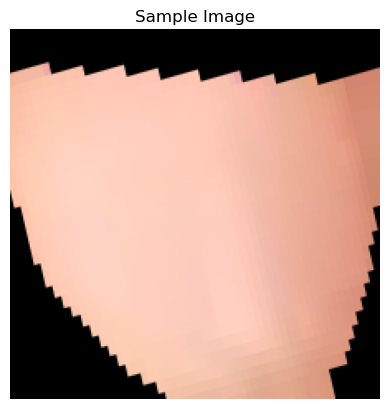

In [16]:
images, labels = next(train_generator)

plt.imshow(images[0])
plt.title('Sample Image')
plt.axis('off')
plt.savefig('sample_nail_image.png', dpi = 300, bbox_inches = 'tight')
plt.show()